## Análisis Univariable de los datos

### By:
Maria Camila Sepúlveda Torres

### Date:
2024-08-21

### Description:

Análisis exploratorio univariable del dataset de admisiones universitarias con el fin de caracterizar individualmente cada variable, identificar valores faltantes, posibles valores atípicos, distribuciones, medidas estadísticas y reglas preliminares de validación para las siguientes etapas del proyecto.


## 📚 Import  libraries

In [2]:
# base libraries for data science
import sys
from pathlib import Path

import pandas as pd

In [3]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [4]:
# print library version for reproducibility
print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]
Pandas version:  3.0.5


## 💾 Load data

In [5]:
# data directory path
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

admission_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admission_type_fixed.parquet"
)

In [6]:
# categorical ordinal variables
cols_categoric = ["University Rating", "SOP", "LOR"]

admission_df[cols_categoric] = admission_df[cols_categoric].astype("category")

In [7]:
admission_df["University Rating"] = pd.Categorical(
    admission_df["University Rating"],
    categories=[1, 2, 3, 4, 5],
    ordered=True,
)

admission_df["SOP"] = pd.Categorical(
    admission_df["SOP"],
    categories=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    ordered=True,
)

admission_df["LOR"] = pd.Categorical(
    admission_df["LOR"],
    categories=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    ordered=True,
)

## 📊 Data description

In [8]:
admission_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   GRE Score          612 non-null    Int16   
 1   TOEFL Score        604 non-null    Int16   
 2   University Rating  617 non-null    category
 3   SOP                607 non-null    category
 4   LOR                615 non-null    category
 5   CGPA               621 non-null    float64 
 6   Research           594 non-null    boolean 
 7   Chance of Admit    623 non-null    float64 
dtypes: Int16(2), boolean(1), category(3), float64(2)
memory usage: 16.7 KB


In [9]:
# size of the dataframe
admission_df.shape

(623, 8)

In [10]:
# sample of the dataframe
admission_df.sample(5)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
202,340,120,5,4.50,4.50,9.91,True,0.97
278,308,103,2,3.00,3.50,8.49,False,0.66
388,296,97,2,1.50,2.00,7.80,False,0.49
371,324,110,3,3.50,3.00,9.22,True,0.89
535,298,105,3,3.50,4.00,8.54,False,0.69


### Nulos

In [11]:
# nulos
admission_df.isnull().sum()

GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64

In [12]:
#Porcentaje de nulos
(admission_df.isnull().mean() * 100).round(2)

GRE Score           1.77
TOEFL Score         3.05
University Rating   0.96
SOP                 2.57
LOR                 1.28
CGPA                0.32
Research            4.65
Chance of Admit     0.00
dtype: float64

In [13]:
# valores exactos de duplicados f
admission_df.duplicated().sum()

np.int64(152)

In [14]:
# valores exactos de duplicados c
admission_df.T.duplicated().sum()

np.int64(0)

In [15]:
# duplicados
admission_df[admission_df.duplicated(keep=False)].sort_values(
    by=list(admission_df.columns)
)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
117,290,104,4,2.00,2.50,7.46,False,0.45
445,290,104,4,2.00,2.50,7.46,False,0.45
571,290,104,4,2.00,2.50,7.46,False,0.45
168,293,97,2,2.00,4.00,7.80,True,0.64
622,293,97,2,2.00,4.00,7.80,True,0.64
...,...,...,...,...,...,...,...,...
143,340,120,4,4.50,4.00,9.92,True,0.97
471,340,120,4,4.50,4.00,9.92,True,0.97
597,340,120,4,4.50,4.00,9.92,True,0.97
81,340,120,4,5.00,5.00,9.50,True,0.96


**Observación:** Se identificaron 152 filas exactamente duplicadas y no se encontraron columnas duplicadas. Antes de eliminar registros duplicados se debe analizar si corresponden a duplicados reales o a observaciones diferentes con las mismas características

In [16]:
# frecuencia de las filas duplicadas

duplicate_counts = (
    admission_df
    .value_counts(dropna=False)
    .reset_index(name="Frequency")
)

duplicate_counts = duplicate_counts[
    duplicate_counts["Frequency"] > 1
]

duplicate_counts.sort_values(
    "Frequency",
    ascending=False
)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Frequency
0,331,120,3,4.00,4.00,8.96,True,0.86,3
1,332,119,4,5.00,4.50,9.24,True,0.90,3
2,323,113,3,4.00,4.00,8.88,True,0.79,3
3,322,107,3,3.50,3.50,8.46,True,0.71,3
4,312,105,2,2.50,3.00,8.12,False,0.64,3
...,...,...,...,...,...,...,...,...,...
106,330,116,5,5.00,4.50,9.36,True,0.93,2
107,322,112,4,4.50,4.50,9.26,True,0.91,2
108,321,109,4,4.00,4.00,9.13,True,0.85,2
109,324,110,4,3.00,3.50,8.97,True,0.84,2


In [17]:
print(
    "Total de registros:",
    len(admission_df)
)

print(
    "Filas que pertenecen a grupos duplicados:",
    admission_df.duplicated(keep=False).sum()
)

print(
    "Copias adicionales:",
    admission_df.duplicated().sum()
)

print(
    "Registros únicos después de eliminar duplicados:",
    len(admission_df.drop_duplicates())
)

Total de registros: 623
Filas que pertenecen a grupos duplicados: 263
Copias adicionales: 152
Registros únicos después de eliminar duplicados: 471


### Análisis de registros duplicados

El conjunto de datos contiene 623 registros. Se identificaron 263 filas que pertenecen a grupos de registros exactamente duplicados y 152 copias adicionales. Al conservar una única ocurrencia de cada combinación, el conjunto de datos contiene 471 registros únicos.

Los registros duplicados presentan coincidencia exacta en todas las variables, incluida la variable objetivo `Chance of Admit`. Debido a que el conjunto de datos no contiene un identificador único del estudiante, no es posible determinar únicamente con esta información si corresponden a estudiantes diferentes con las mismas características o a duplicaciones generadas durante la construcción del conjunto de datos.

Sin embargo, mantener copias exactamente iguales durante la etapa de modelado podría generar fuga de información si registros idénticos quedan distribuidos entre los conjuntos de entrenamiento y prueba, produciendo una estimación demasiado optimista del desempeño del modelo.

Por esta razón, los duplicados exactos se consideran un aspecto de calidad de los datos que requiere tratamiento antes del modelado. Se propone conservar una única ocurrencia de cada registro exactamente duplicado, obteniendo 471 registros únicos.

In [15]:
admission_df.describe()

,GRE Score,TOEFL Score,CGPA,Chance of Admit
count,612.00,604.00,621.00,623.00
mean,317.09,107.87,8.64,0.73
std,11.75,6.12,0.59,0.14
min,290.00,92.00,6.80,0.34
25%,309.00,104.00,8.22,0.64
50%,317.00,108.00,8.65,0.73
75%,326.00,112.00,9.10,0.84
max,340.00,120.00,9.92,0.97


In [16]:
# categorical columns description
admission_df.describe(include="category")

,University Rating,SOP,LOR
count,617,607.00,615.00
unique,5,9.00,9.00
top,3,4.00,3.00
freq,200,111.00,137.00


## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


### Chance of Admit

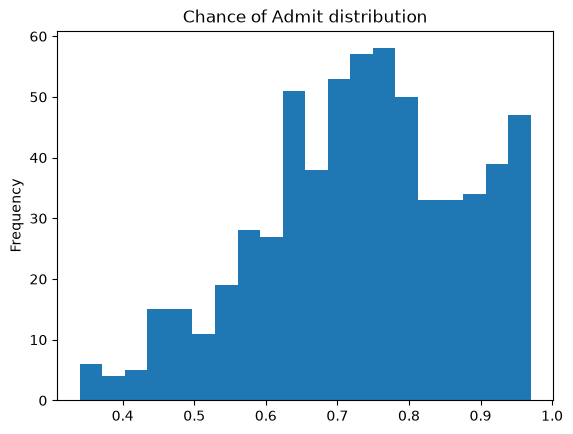

In [17]:
admission_df["Chance of Admit"].plot(
    kind="hist",
    bins=20,
    title="Chance of Admit distribution",
);

### TENDENCIA CENTRAL

In [18]:
admission_df["Chance of Admit"].describe()

count   623.00
mean      0.73
std       0.14
min       0.34
25%       0.64
50%       0.73
75%       0.84
max       0.97
Name: Chance of Admit, dtype: float64

In [23]:
# MODA
admission_df["Chance of Admit"].mode()

0   0.64
Name: Chance of Admit, dtype: float64

### MEDIDAS DE DISPERSION, SKEWNESS Y KUTOSIS

In [19]:
column = "Chance of Admit"

data_range = admission_df[column].max() - admission_df[column].min()
iqr = admission_df[column].quantile(0.75) - admission_df[column].quantile(0.25)
variance = admission_df[column].var()
skewness = admission_df[column].skew()
kurtosis = admission_df[column].kurt()

print("Range:", data_range)
print("IQR:", iqr)
print("Variance:", variance)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Range: 0.6299999999999999
IQR: 0.19999999999999996
Variance: 0.02023210014812674
Skewness: -0.3814245570184339
Kurtosis: -0.36578097246979446


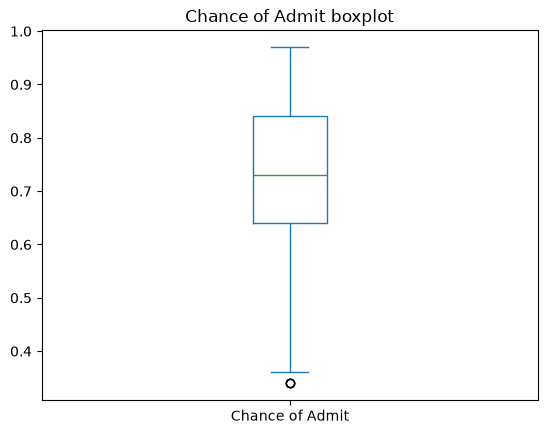

In [20]:
admission_df["Chance of Admit"].plot(
    kind="box",
    title="Chance of Admit boxplot",
);

In [22]:
column = "Chance of Admit"

q1 = admission_df[column].quantile(0.25)
q3 = admission_df[column].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = admission_df[
    (admission_df[column] < lower_limit)
    | (admission_df[column] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of potential outliers:", len(outliers))

outliers[[column]]

Lower limit: 0.3400000000000001
Upper limit: 1.14
Number of potential outliers: 3


,Chance of Admit
92,0.34
376,0.34
420,0.34


**Observación:** El criterio IQR identificó 3 observaciones potencialmente atípicas en la variable `Chance of Admit`, todas con un valor de 0.34. Estos registros se encuentran prácticamente sobre el límite inferior calculado (0.34). Dado que el valor se encuentra dentro del rango válido de una probabilidad (0 a 1), no existe evidencia suficiente para considerarlo un error. Por lo tanto, las observaciones se conservarán para análisis posteriores.

### TIPO DE DISTIBUCION
La variable `Chance of Admit` presenta una distribución con ligera asimetría negativa (skewness = -0.38), lo que indica una mayor concentración de observaciones en valores medios y altos y una cola hacia los valores inferiores. La media y la mediana son aproximadamente iguales (0.73), por lo que la asimetría no es pronunciada.

La kurtosis es de -0.37, indicando una distribución ligeramente más aplanada que una distribución normal. A partir del histograma y de estas medidas descriptivas, no se observa una distribución perfectamente normal.

#### IMPORTANCIA DE LA VARIABLE

`Chance of Admit` es la variable objetivo del proyecto, por lo que es fundamental para los análisis posteriores y para la posible construcción de un modelo predictivo.

Como representa una probabilidad de admisión, sus valores deben encontrarse en el intervalo de 0 a 1. Los valores observados en el dataset se encuentran entre 0.34 y 0.97, por lo que cumplen con esta regla de validación.

### GRE Score

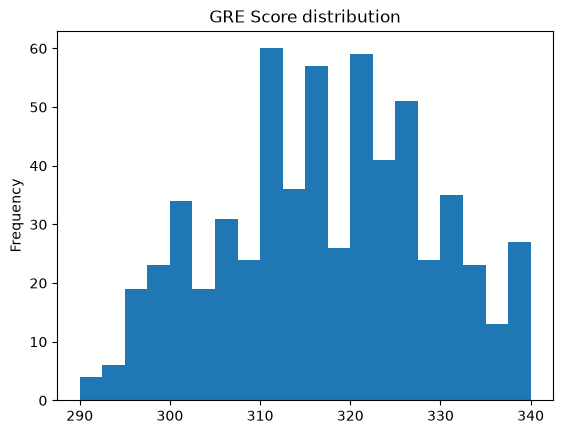

In [24]:
admission_df["GRE Score"].plot(
    kind="hist",
    bins=20,
    title="GRE Score distribution",
);

### TENDENCIA CENTRAL

In [25]:
admission_df["GRE Score"].describe()

count   612.00
mean    317.09
std      11.75
min     290.00
25%     309.00
50%     317.00
75%     326.00
max     340.00
Name: GRE Score, dtype: Float64

In [26]:
# moda
admission_df["GRE Score"].mode()

0    312
Name: GRE Score, dtype: Int16

### MEDIDAS DE DISPERSION, SKEWNESS Y KUTOSIS

In [27]:
column = "GRE Score"

data_range = admission_df[column].max() - admission_df[column].min()
iqr = admission_df[column].quantile(0.75) - admission_df[column].quantile(0.25)
variance = admission_df[column].var()
skewness = admission_df[column].skew()
kurtosis = admission_df[column].kurt()

print("Range:", data_range)
print("IQR:", iqr)
print("Variance:", variance)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Range: 50
IQR: 17
Variance: 138.01064364643835
Skewness: -0.08503142522886213
Kurtosis: -0.7341715983281234


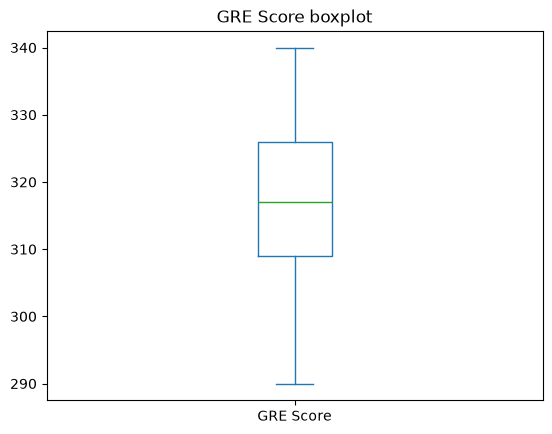

In [28]:
admission_df["GRE Score"].plot(
    kind="box",
    title="GRE Score boxplot",
);

In [29]:
column = "GRE Score"

q1 = admission_df[column].quantile(0.25)
q3 = admission_df[column].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = admission_df[
    (admission_df[column] < lower_limit)
    | (admission_df[column] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of potential outliers:", len(outliers))

outliers[[column]]

Lower limit: 283.5
Upper limit: 351.5
Number of potential outliers: 0


,GRE Score


#### TIPO DE DISTIBUCION

La variable `GRE Score` presenta una distribución aproximadamente simétrica, con una media de 317.09 y una mediana de 317. La moda es 312.

El coeficiente de asimetría (skewness) es de -0.09, valor cercano a cero, lo que indica que no existe una asimetría importante. La kurtosis es de -0.73, indicando una distribución más aplanada que una distribución normal.

Los valores se encuentran entre 290 y 340, con un rango de 50, un IQR de 17, una varianza de 138.01 y una desviación estándar de 11.75.

#### ATIPICOS

El análisis mediante boxplot y el criterio IQR no identificó valores atípicos en `GRE Score`. Los límites calculados fueron 283.5 y 351.5, mientras que los valores observados se encuentran entre 290 y 340.

No se identifican valores fuera del rango observado ni evidencia de errores evidentes en esta variable. Los valores nulos representan el 1.77 % de los registros y deberán ser considerados en la etapa de preparación de los datos.

#### IMPORTANCIA DE LA VARIABLE

`GRE Score` puede ser una variable útil para el proyecto, ya que representa el desempeño obtenido por el estudiante en el examen GRE y puede aportar información para explicar o predecir la probabilidad de admisión.

Como regla de validación para este conjunto de datos, los valores observados se encuentran entre 290 y 340 y corresponden a valores enteros. También se deberá controlar la presencia de valores nulos antes de utilizar esta variable en un modelo.

#### TOEFL Score

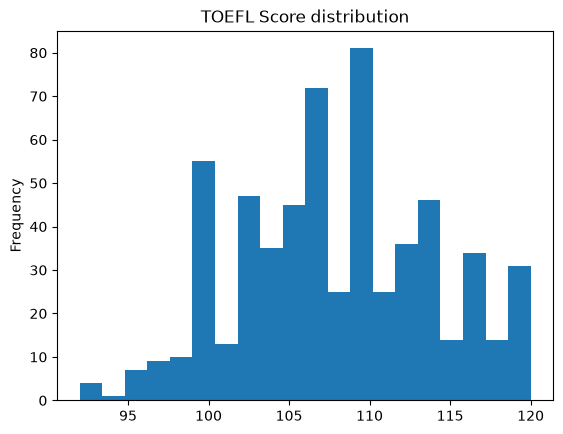

In [30]:
admission_df["TOEFL Score"].plot(
    kind="hist",
    bins=20,
    title="TOEFL Score distribution",
);

### TENDENCIA CENTRAL

In [31]:
admission_df["TOEFL Score"].describe()

count   604.00
mean    107.87
std       6.12
min      92.00
25%     104.00
50%     108.00
75%     112.00
max     120.00
Name: TOEFL Score, dtype: Float64

In [32]:
# moda
admission_df["TOEFL Score"].mode()

0    110
Name: TOEFL Score, dtype: Int16

### MEDIDAS DE DISPERSION, SKEWNESS Y KUTOSIS

In [33]:
column = "TOEFL Score"

data_range = admission_df[column].max() - admission_df[column].min()
iqr = admission_df[column].quantile(0.75) - admission_df[column].quantile(0.25)
variance = admission_df[column].var()
skewness = admission_df[column].skew()
kurtosis = admission_df[column].kurt()

print("Range:", data_range)
print("IQR:", iqr)
print("Variance:", variance)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Range: 28
IQR: 8
Variance: 37.4131632126344
Skewness: 0.02986004148237567
Kurtosis: -0.6281829874568592


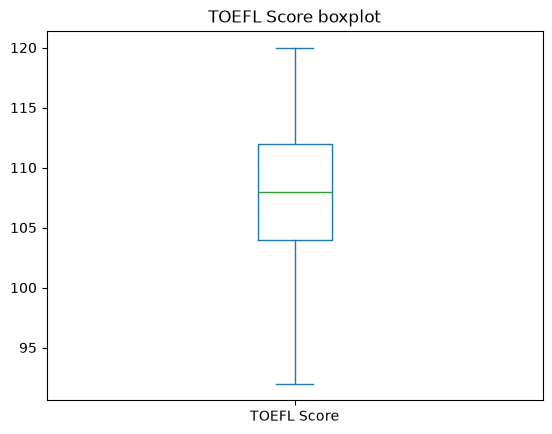

In [34]:
admission_df["TOEFL Score"].plot(
    kind="box",
    title="TOEFL Score boxplot",
);

In [35]:
column = "TOEFL Score"

q1 = admission_df[column].quantile(0.25)
q3 = admission_df[column].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = admission_df[
    (admission_df[column] < lower_limit)
    | (admission_df[column] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of potential outliers:", len(outliers))

outliers[[column]]

Lower limit: 92.0
Upper limit: 124.0
Number of potential outliers: 0


,TOEFL Score


#### TIPO DE DISTIBUCION
La variable `TOEFL Score` presenta una distribución aproximadamente simétrica. La media es 107.87, la mediana es 108 y la moda es 110.

El coeficiente de asimetría (skewness) es de 0.03, valor cercano a cero, lo que indica que no existe una asimetría importante. La kurtosis es de -0.63, indicando una distribución más aplanada que una distribución normal.

Los valores se encuentran entre 92 y 120, con un rango de 28, un IQR de 8, una varianza de 37.41 y una desviación estándar de 6.12.

#### ATIPICOS
El análisis mediante boxplot y el criterio IQR no identificó valores atípicos en `TOEFL Score`. Los límites calculados fueron 92 y 124, mientras que los valores observados se encuentran entre 92 y 120.

No se identifican valores fuera de estos límites ni evidencia de errores evidentes en la variable. Los valores nulos representan el 3.05 % de los registros y deberán ser considerados en la etapa de preparación de los datos.

#### IMPORTANCIA DE LA VARIABLE
`TOEFL Score` puede ser una variable útil para el proyecto, ya que representa el desempeño del estudiante en el examen TOEFL y puede aportar información para explicar o predecir la probabilidad de admisión.

Como regla de validación para este conjunto de datos, los valores observados se encuentran entre 92 y 120 y corresponden a valores enteros. También se deberá controlar la presencia de valores nulos antes de utilizar esta variable en un modelo.

#### CGPA

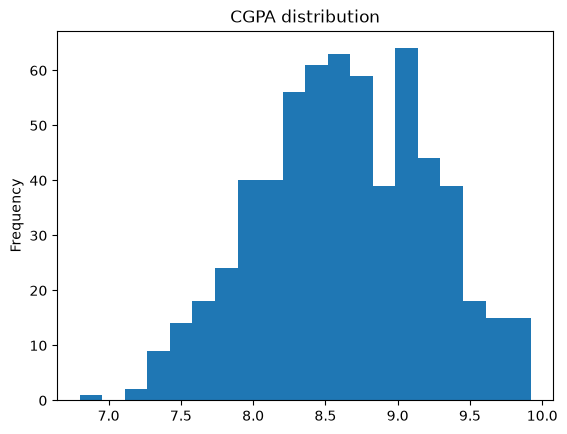

In [36]:
admission_df["CGPA"].plot(
    kind="hist",
    bins=20,
    title="CGPA distribution",
);

### TENDENCIA CENTRAL

In [37]:
admission_df["CGPA"].describe()

count   621.00
mean      8.64
std       0.59
min       6.80
25%       8.22
50%       8.65
75%       9.10
max       9.92
Name: CGPA, dtype: float64

In [38]:
# moda
admission_df["CGPA"].mode()

0   8.56
Name: CGPA, dtype: float64

### MEDIDAS DE DISPERSION, SKEWNESS Y KUTOSIS

In [39]:
column = "CGPA"

data_range = admission_df[column].max() - admission_df[column].min()
iqr = admission_df[column].quantile(0.75) - admission_df[column].quantile(0.25)
variance = admission_df[column].var()
skewness = admission_df[column].skew()
kurtosis = admission_df[column].kurt()

print("Range:", data_range)
print("IQR:", iqr)
print("Variance:", variance)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Range: 3.12
IQR: 0.879999999999999
Variance: 0.3475665497896213
Skewness: -0.10965570568311073
Kurtosis: -0.44572884301307436


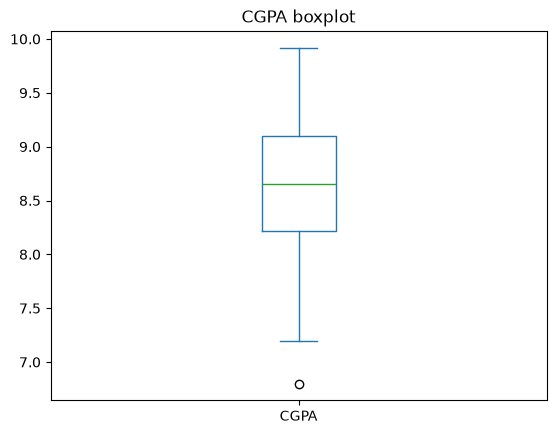

In [40]:
admission_df["CGPA"].plot(
    kind="box",
    title="CGPA boxplot",
);

In [41]:
column = "CGPA"

q1 = admission_df[column].quantile(0.25)
q3 = admission_df[column].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = admission_df[
    (admission_df[column] < lower_limit)
    | (admission_df[column] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of potential outliers:", len(outliers))

outliers[[column]]

Lower limit: 6.900000000000002
Upper limit: 10.419999999999998
Number of potential outliers: 1


,CGPA
58,6.80


#### TIPO DE DISTIBUCION
La variable `CGPA` presenta una distribución aproximadamente simétrica. La media es 8.64, la mediana es 8.65 y la moda es 8.56.

El coeficiente de asimetría (skewness) es de -0.11, valor cercano a cero, lo que indica que no existe una asimetría importante. La kurtosis es de -0.45, indicando una distribución ligeramente más aplanada que una distribución normal.

Los valores se encuentran entre 6.80 y 9.92, con un rango de 3.12, un IQR de 0.88, una varianza de 0.35 y una desviación estándar de 0.59.

#### ATIPICOS
El análisis mediante boxplot y el criterio IQR identificó 1 observación potencialmente atípica en la variable `CGPA`, correspondiente a un valor de 6.80. El límite inferior calculado fue 6.90 y el límite superior fue 10.42.

Aunque el valor 6.80 se encuentra por debajo del límite inferior establecido mediante el criterio IQR, no existe evidencia suficiente para considerarlo un error, por lo que se conservará para análisis posteriores. Los valores nulos representan el 0.32 % de los registros y deberán ser considerados durante la preparación de los datos.

#### IMPORTANCIA DE LA VARIABLE
`CGPA` puede ser una variable útil para el proyecto, ya que representa el desempeño académico del estudiante y puede aportar información para explicar o predecir la probabilidad de admisión.

Como regla de validación para este conjunto de datos, los valores observados de `CGPA` se encuentran entre 6.80 y 9.92 y corresponden a valores numéricos decimales. También se deberá controlar la presencia de valores nulos antes de utilizar esta variable en un modelo.

### University Rating

In [43]:
admission_df["University Rating"].value_counts().sort_index()

University Rating
1     33
2    158
3    200
4    118
5    108
Name: count, dtype: int64

In [44]:
admission_df["University Rating"].value_counts(
    normalize=True
).sort_index() * 100

University Rating
1    5.35
2   25.61
3   32.41
4   19.12
5   17.50
Name: proportion, dtype: float64

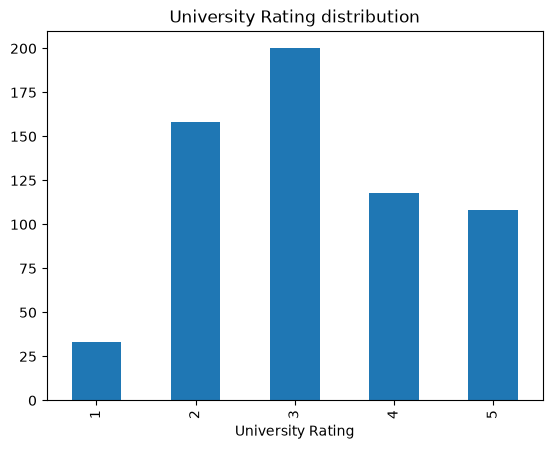

In [45]:
admission_df["University Rating"].value_counts().sort_index().plot(
    kind="bar",
    title="University Rating distribution",
);

In [46]:
# unicos
admission_df["University Rating"].unique()

[4, 3, 2, 5, 1, NaN]
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

#### Distribucion

La variable `University Rating` es una variable categórica ordinal con cinco niveles ordenados de 1 a 5. La categoría más frecuente es el nivel 3, con 200 observaciones (32.41 %), seguida del nivel 2 con 158 observaciones (25.61 %).

Los niveles 4 y 5 representan el 19.12 % y 17.50 % de las observaciones, respectivamente, mientras que el nivel 1 es el menos frecuente con 33 observaciones (5.35 %).

Los valores observados corresponden únicamente a las categorías esperadas 1, 2, 3, 4 y 5, por lo que no se identificaron categorías fuera de la escala definida.

La variable presenta valores nulos, correspondientes al 0.96 % de los registros. Estos deberán ser considerados durante la etapa de preparación de los datos.

Debido a que `University Rating` es una variable categórica ordinal, no se aplica la detección de valores atípicos mediante el criterio IQR.

#### IMPORTANCIA DE LA VARIABLE

`University Rating` puede ser una variable útil para el proyecto, ya que representa una valoración ordinal de la universidad y puede aportar información para explicar o predecir la probabilidad de admisión.

Como regla de validación, únicamente se deben aceptar las categorías 1, 2, 3, 4 y 5, manteniendo su orden natural. También se deberá controlar la presencia de valores nulos antes de utilizar esta variable en un modelo.

#### SOP

In [47]:
admission_df["SOP"].value_counts().sort_index()

SOP
1.00      6
1.50     31
2.00     52
2.50     60
3.00     91
3.50    108
4.00    111
4.50     87
5.00     61
Name: count, dtype: int64

In [48]:
admission_df["SOP"].value_counts(
    normalize=True
).sort_index() * 100

SOP
1.00    0.99
1.50    5.11
2.00    8.57
2.50    9.88
3.00   14.99
3.50   17.79
4.00   18.29
4.50   14.33
5.00   10.05
Name: proportion, dtype: float64

In [49]:
# moda
admission_df["SOP"].mode()

0   4.00
Name: SOP, dtype: category
Categories (9, float64): [1.00 < 1.50 < 2.00 < 2.50 ... 3.50 < 4.00 < 4.50 < 5.00]

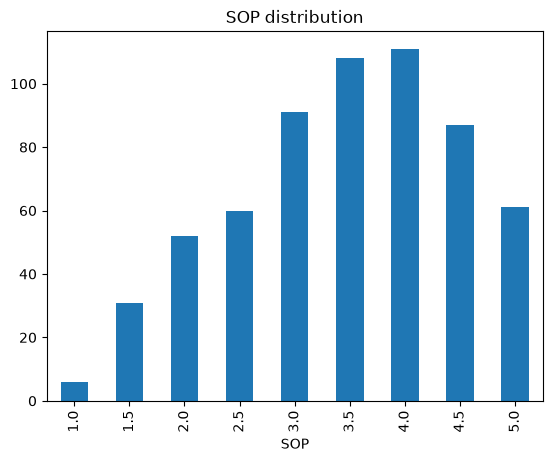

In [50]:
admission_df["SOP"].value_counts().sort_index().plot(
    kind="bar",
    title="SOP distribution",
);

In [51]:
# unicos
admission_df["SOP"].unique()

[4.50, 4.00, 3.00, 3.50, 2.00, 5.00, 1.50, 1.00, 2.50, NaN]
Categories (9, float64): [1.00 < 1.50 < 2.00 < 2.50 ... 3.50 < 4.00 < 4.50 < 5.00]

#### Distribucion

La variable `SOP` es una variable categórica ordinal con nueve niveles ordenados entre 1.0 y 5.0, en incrementos de 0.5. La categoría más frecuente es 4.0, con 111 observaciones (18.29 %), seguida de 3.5 con 108 observaciones (17.79 %) y 3.0 con 91 observaciones (14.99 %).

Las categorías menos frecuentes son 1.0 con 6 observaciones (0.99 %) y 1.5 con 31 observaciones (5.11 %).

#### atipico

Los valores observados corresponden únicamente a las categorías esperadas entre 1.0 y 5.0, en incrementos de 0.5, por lo que no se identificaron categorías fuera de la escala definida.

La variable presenta valores nulos, correspondientes al 2.57 % de los registros. Estos deberán ser considerados durante la etapa de preparación de los datos.

Debido a que `SOP` es una variable categórica ordinal, no se aplica la detección de valores atípicos mediante el criterio IQR.

#### IMPORTANCIA DE LA VARIABLE

`SOP` puede ser una variable útil para el proyecto, ya que representa la valoración del Statement of Purpose del estudiante y puede aportar información para explicar o predecir la probabilidad de admisión.

Como regla de validación, únicamente se deben aceptar valores entre 1.0 y 5.0 en incrementos de 0.5, manteniendo el orden natural de las categorías. También se deberá controlar la presencia de valores nulos antes de utilizar esta variable en un modelo.

#### LOR

In [52]:
admission_df["LOR"].value_counts().sort_index()

LOR
1.00      1
1.50      7
2.00     45
2.50     58
3.00    137
3.50    115
4.00    118
4.50     77
5.00     57
Name: count, dtype: int64

In [57]:
admission_df["LOR"].value_counts(
    normalize=True
).sort_index() * 100

LOR
1.00    0.16
1.50    1.14
2.00    7.32
2.50    9.43
3.00   22.28
3.50   18.70
4.00   19.19
4.50   12.52
5.00    9.27
Name: proportion, dtype: float64

In [ ]:
# moda
admission_df["LOR"].mode()

0   3.00
Name: LOR, dtype: category
Categories (9, float64): [1.00 < 1.50 < 2.00 < 2.50 ... 3.50 < 4.00 < 4.50 < 5.00]

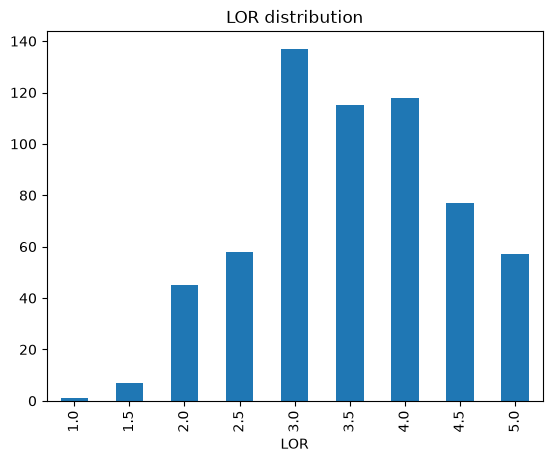

In [54]:
admission_df["LOR"].value_counts().sort_index().plot(
    kind="bar",
    title="LOR distribution",
);

In [56]:
# unicos
admission_df["LOR"].unique()

[4.50, 3.50, 2.50, 3.00, 4.00, 1.50, 2.00, 5.00, 1.00, NaN]
Categories (9, float64): [1.00 < 1.50 < 2.00 < 2.50 ... 3.50 < 4.00 < 4.50 < 5.00]

#### Distribucion

La variable `LOR` es una variable categórica ordinal con nueve niveles ordenados entre 1.0 y 5.0, en incrementos de 0.5. La categoría más frecuente es 3.0, con 137 observaciones (22.28 %), seguida de 4.0 con 118 observaciones (19.19 %) y 3.5 con 115 observaciones (18.70 %).

Las categorías menos frecuentes son 1.0 con 1 observación (0.16 %) y 1.5 con 7 observaciones (1.14 %).

#### ATIPICOS

Los valores observados corresponden únicamente a las categorías esperadas entre 1.0 y 5.0, en incrementos de 0.5, por lo que no se identificaron categorías fuera de la escala definida.

La variable presenta valores nulos, correspondientes al 1.28 % de los registros. Estos deberán ser considerados durante la etapa de preparación de los datos.

Debido a que `LOR` es una variable categórica ordinal, no se aplica la detección de valores atípicos mediante el criterio IQR.

#### IMPORTANCIA DE LA VARIABLE

`LOR` puede ser una variable útil para el proyecto, ya que representa la valoración de la carta de recomendación del estudiante y puede aportar información para explicar o predecir la probabilidad de admisión.

Como regla de validación, únicamente se deben aceptar valores entre 1.0 y 5.0 en incrementos de 0.5, manteniendo el orden natural de las categorías. También se deberá controlar la presencia de valores nulos antes de utilizar esta variable en un modelo.

#### Research

In [58]:
admission_df["Research"].value_counts()

Research
True     327
False    267
Name: count, dtype: Int64

In [59]:
admission_df["Research"].value_counts(
    normalize=True
) * 100

Research
True    55.05
False   44.95
Name: proportion, dtype: Float64

In [62]:
# moda
admission_df["Research"].mode()

0    True
Name: Research, dtype: boolean

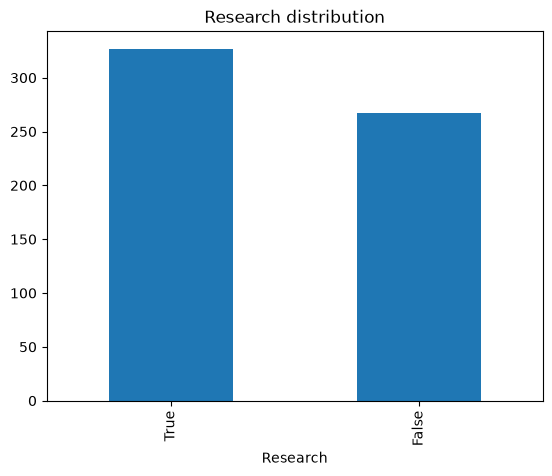

In [60]:
admission_df["Research"].value_counts().plot(
    kind="bar",
    title="Research distribution",
);

In [61]:
# UNICOS
admission_df["Research"].unique()

<BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean

#### Distribucion

La variable `Research` es una variable booleana que indica si el estudiante cuenta o no con experiencia en investigación.

Entre los valores no nulos, `True` es la categoría más frecuente, con 327 observaciones (55.05 %), mientras que `False` presenta 267 observaciones (44.95 %). Por lo tanto, la moda de la variable es `True`.

La distribución entre ambas categorías es relativamente equilibrada, aunque existe una ligera mayor proporción de estudiantes con experiencia en investigación.

#### ATIPICO

Los valores no nulos observados corresponden únicamente a las categorías booleanas esperadas `True` y `False`, por lo que no se identificaron categorías inválidas.

La variable presenta valores nulos, correspondientes al 4.65 % de los registros, siendo la variable con mayor porcentaje de datos faltantes del conjunto analizado. Estos valores deberán ser considerados durante la etapa de preparación de los datos.

Debido a que `Research` es una variable booleana, no se aplica la detección de valores atípicos mediante el criterio IQR.

#### IMPORTANCIA DE LA VARIABLE

`Research` puede ser una variable útil para el proyecto, ya que representa si el estudiante cuenta con experiencia en investigación y puede aportar información para explicar o predecir la probabilidad de admisión.

Como regla de validación, únicamente se deben aceptar los valores booleanos `True` y `False`. También se deberá definir una estrategia para el tratamiento de los valores nulos antes de utilizar esta variable en un modelo.

## 💡 Proposals and Ideas

From the results obtained, what ideas or proposals can be generated to continue with the project


## 📖 References